# Dataset Partidos

En este notebook unificamos los datos correspondientes a los partidos de los principales equipos deportivos de Chicago (`sportsref_download*.csv`), incluyendo baloncesto, béisbol, fútbol americano, hockey y fútbol. 

Tenemos varios archivos por equipo de Sports Reference con datos de los partidos, cada uno correspondiente a una temporada. El objetivo es juntar todos estos archivos en un único conjunto de datos y realizar una primera limpieza. Como resultado final, obtenemos un conjunto de datos que contiene las fechas de los partidos jugados en casa, el cual utilizaremos más adelante para incorporarlo al modelo de predicción del tráfico.


## 0. Importación de paquetes

In [ ]:
from EDA_general import *
import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap

import pandas as pd
import glob
import lxml
import html5lib
import xlrd
import requests

from pathlib import Path

## 1. Descarga y limpieza

### 1.1. Chicago Bears (Fútbol Americano)

Primero de todo, hacemos un análisis general de uno de los archivos para ver las dimensiones y tipo de columnas que tienen (todos los archivos tienen las mismas columnas pero no la misma cantidad de filas ya que no todos los años se juegan la misma cantidad de partidos).

In [2]:
ejemplo_bears = pd.read_html("data/ChicagoBears/sportsref_download15.xls")[0]
print(ejemplo_bears.shape)
print(ejemplo_bears.head())

(17, 25)
  Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0 Unnamed: 3_level_0  \
                Week                Day               Date Unnamed: 3_level_1   
0                  1                Sun       September 13          1:00PM ET   
1                  2                Sun       September 20          1:00PM ET   
2                  3                Sun       September 27          4:26PM ET   
3                  4                Sun          October 4          1:02PM ET   
4                  5                Sun         October 11          1:02PM ET   

  Unnamed: 4_level_0 Unnamed: 5_level_0 Unnamed: 6_level_0 Unnamed: 7_level_0  \
  Unnamed: 4_level_1 Unnamed: 5_level_1                 OT                Rec   
0           boxscore                  L                NaN                0-1   
1           boxscore                  L                NaN                0-2   
2           boxscore                  L                NaN                0-3   
3           boxsco

Las columnas vienen a dos niveles (`Score/Tm`, `Score/Opp`...) y hay varias columnas sin nombre (`Unnamed: X`) pero que tienen el contenido en la segunda fila: la hora del partido, el enlace al boxscore, el resultado (ganar `W`/perder `L`) y, la más importante, una columna que tiene valor `@` cuando el partido fue fuera de casa y `NaN` cuando fue en casa.

Obervamos que la fecha no trae el año, es decir, la columna `Date` solo tiene mes y día (`"September 13"`). Aun así, como los archivos han sido descargados por año, podemos saber de que temporada es cada uno, pues en el nombre tiene un número que lo indica (`download15` de 2015, `download16` de 2016, etc.).

Nota: como queremos fechas desde 2015 a 2026, no necesitamos más archivos. Además, la temporada 2014 acabo en diciembre de ese año, por lo que no hay partidos en 2015.

In [3]:
def extraer_temporada(ruta):
    """ Esta función extrae el número al final del nombre del archivo 
    y lo convierte en el año de la temporada.
    """

    n = int(ruta.split("download")[1].split(".")[0])
    return 2000 + n

#### 1.1.1. Estructura de cada temporada

Además de las 16-17 semanas de partidos, algunos archivos tienen alguna fila más:

- `Bye Week` en la semana de descanso.
- Una fila `Playoffs` que hace de separador antes de meter los
  partidos de playoffs si los hubo.
- Los partidos de playoffs.

In [4]:
def leer_temporada(ruta):
    """Esta función lee un archivo y devuelve un df con una fila
    por partido jugado en casa de la fecha completa (con hora)."""
    año = extraer_temporada(ruta)

    df = pd.read_html(ruta)[0]
    # try:
    #     df = pd.read_html(ruta)[0]
    # except Exception:
    #     df = pd.read_excel(ruta)

    # juntamos la cabeceras (porque unas vienen a 2 niveles y otras a 1)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[1] if "Unnamed" in str(c[0]) else c[0] for c in df.columns]
    df.columns = [str(c) for c in df.columns]

    # la columna de local/visitante está justo a la izquierda de "Opp"
    opp_idx = df.columns.get_loc("Opp")
    local = df.columns[opp_idx - 1]

    # quitamos la semana de descanso y la fila separadora de playoffs
    df = df[df["Opp"].notna() & (df["Opp"] != "Bye Week")].copy()

    df["casa"] = df[local].isna()  # NaN = local, @ = visitante
    df = df[df["casa"]]

    # reconstruimos la fecha completa 
    # como la temporada empieza en septiembre y acaba en enero o febrero, 
    # los partidos de enero/febrero son ya del año siguiente al de la temporada

    # la hora es la que esta después de "Date"
    hora = df.columns[df.columns.get_loc("Date") + 1]
    # Quitamos el sufijo " ET", y los espacios antes de AM/PM
    hora_str = (
        df[hora]
        .str.replace(" ET", "", regex=False)
        .str.replace(" PM", "PM", regex=False)
        .str.replace(" AM", "AM", regex=False)
    )

    fecha = pd.to_datetime(df["Date"] + f" {año} " + hora_str, format="%B %d %Y %I:%M%p", errors="coerce")
    año_siguiente = fecha.dt.month.isin([1, 2])
    fecha = fecha.where(
        ~año_siguiente,
        pd.to_datetime(df["Date"] + f" {año + 1} " + hora_str, format="%B %d %Y %I:%M%p", errors="coerce")
    )

    df["date"] = fecha

    return df[["date"]]

In [5]:
# probamos la función
leer_temporada("data/ChicagoBears/sportsref_download15.xls")

,date
0,2015-09-13 13:00:00
1,2015-09-20 13:00:00
3,2015-10-04 13:02:00
7,2015-11-01 13:00:00
10,2015-11-22 13:02:00
12,2015-12-06 13:02:00
13,2015-12-13 13:02:00
16,2016-01-03 13:02:00


Vemos que los Chicago Bears jugaron 8 partidos en casa en la temporada 2015-2016, todos a las 13:00 (algunos a las 13:02 por retraso).

#### 1.1.2. Unimos todas las temporadas

In [6]:
paths_bears = sorted(glob.glob("data/ChicagoBears/sportsref_download*.xls"))
print(f"Archivos encontrados: {len(paths_bears)}")

df_bears = pd.concat([leer_temporada(p) for p in paths_bears], ignore_index=True)
print(f"Total de partidos (todas las temporadas): {len(df_bears)}")
print(f"Fechas que no se pudieron parsear: {df_bears['date'].isna().sum()}")

Archivos encontrados: 12
Total de partidos (todas las temporadas): 103
Fechas que no se pudieron parsear: 0


Los Chicago Bears tienen 103 partidos en total jugados en casa entre las 12 temporadas (2015-2026, incluyendo pretemporada, temporada normal y playoffs), sin ninguna fecha sin parsear. La temporada 2026 todavía no se ha jugado, así que esos partidos son del calendario previsto, no resultados.

#### 1.1.3. Localización

Como el dataset no trae coordenadas, añadimos las coordenadas de su campo (sacadas de OpenStreetMap) como columna fija. En este caso los Chicago Bears juegan en `Soldier Field`.

In [7]:
soldier_field_lat = 41.862470
soldier_field_lon = -87.616724

df_bears['latitude'] = soldier_field_lat
df_bears['longitude'] = soldier_field_lon

print(df_bears.head())
print(df_bears.tail())

                 date  latitude  longitude
0 2015-09-13 13:00:00  41.86247 -87.616724
1 2015-09-20 13:00:00  41.86247 -87.616724
2 2015-10-04 13:02:00  41.86247 -87.616724
3 2015-11-01 13:00:00  41.86247 -87.616724
4 2015-11-22 13:02:00  41.86247 -87.616724
                   date  latitude  longitude
98  2026-11-08 20:20:00  41.86247 -87.616724
99  2026-11-22 13:00:00  41.86247 -87.616724
100 2026-12-06 13:00:00  41.86247 -87.616724
101 2026-12-25 13:00:00  41.86247 -87.616724
102 2027-01-03 16:25:00  41.86247 -87.616724


El resultado final (`df_beas`) tiene una fila por cada partido en casa de
los Chicago Bears entre 2015 y 2026 (temporada regular, pretemporada y playoffs),
con la fecha y las coordenadas de Soldier Field.

### 1.2. Chicago Bulls (Baloncesto)

Primero de todo, hacemos un análisis general de uno de los archivos para ver las dimensiones y tipo de columnas que tienen. Esta vez si que tenemos partidos en 2015 en la temporada de 2014-2015, por lo que empezaremos con el archivo de 2014.

In [8]:
ejemplo_bulls = pd.read_html("data/ChicagoBulls/sportsref_download14.xls")[0]
print(ejemplo_bulls.shape)
print(ejemplo_bulls.head())

(94, 17)
   G               Date Start (ET) Unnamed: 3 Unnamed: 4 Unnamed: 5  \
0  1  Wed, Oct 29, 2014      8:00p        NaN  Box Score          @   
1  2  Fri, Oct 31, 2014      8:00p        NaN  Box Score        NaN   
2  3   Sat, Nov 1, 2014      8:00p        NaN  Box Score          @   
3  4   Tue, Nov 4, 2014      8:00p        NaN  Box Score        NaN   
4  5   Wed, Nov 5, 2014      8:00p        NaN  Box Score          @   

                 Opponent Unnamed: 7 Unnamed: 8   Tm  Opp  W  L Streak  \
0         New York Knicks          W        NaN  104   80  1  0    W 1   
1     Cleveland Cavaliers          L         OT  108  114  1  1    L 1   
2  Minnesota Timberwolves          W        NaN  106  105  2  1    W 1   
3           Orlando Magic          W        NaN   98   90  3  1    W 2   
4         Milwaukee Bucks          W        NaN   95   86  4  1    W 3   

   Attend.   LOG  Notes  
0    19812  2:12    NaN  
1    22879  2:43    NaN  
2    19356  2:26    NaN  
3    21809  2:1

#### 1.2.1. Unir Playoffs

Como en este equipo los playoffs estan en un archivo a parte (de las temporadas 2014, 2016 y 2021), vamos a juntarlos con sus años correspondientes y vamos a reescribir los nombres para poder usar las funciones creadas en el apartado de Chicago Bears.

In [ ]:
def unir_temporada(ruta_regular):
    """
    Esta función une un archivo de temporada regular con su correspondiente
    archivo de playoffs.
    """

    ruta_regular = Path(ruta_regular)
    ruta_playoffs = ruta_regular.with_name(
        ruta_regular.stem + "(playoffs)" + ruta_regular.suffix
    )

    # leemos las tablas
    df_regular = pd.read_html(ruta_regular)[0]
    df_playoffs = pd.read_html(ruta_playoffs)[0]

    # unimos tablas
    df = pd.concat([df_regular, df_playoffs], ignore_index=True)

    # guardar como HTML (con extensión .xls)
    with open(ruta_regular, "w", encoding="utf-8") as f:
        f.write(df.to_html(index=False))

    # eliminamos playoffs
    ruta_playoffs.unlink()

In [10]:
# unir_temporada("data/ChicagoBulls/sportsref_download14.xls")
# unir_temporada("data/ChicagoBulls/sportsref_download16.xls")
# unir_temporada("data/ChicagoBulls/sportsref_download21.xls")

#### 1.2.2. Estructura de cada temporada

Estos archivos no tienen el mismo formato que el de los partidos de los Chicago Bears, por lo tanto vamos a modificar un poco la funcion `leer_temporada` para poder usarlo con estos nuevos archivos.

In [11]:
def leer_temporada(ruta):
    """
    Esta función lee un archivo y devuelve un df con una fila
    por partido jugado en casa de la fecha completa (con hora).
    """

    df = pd.read_html(ruta)[0]

    # quitamos posibles filas repetidas de cabecera
    df = df[df["Date"] != "Date"].copy()

    # la columna anterior a Opponent indica si es local o visitante
    opp_idx = df.columns.get_loc("Opponent")
    local = df.columns[opp_idx - 1]

    # NaN = local, @ = visitante
    df["casa"] = df[local].isna()
    df = df[df["casa"]].copy()

    # limpiamos la hora
    hora = (
        df["Start (ET)"]
        .str.replace("a", "AM", regex=False)
        .str.replace("p", "PM", regex=False)
    )

    # construimos la fecha completa
    df["date"] = pd.to_datetime(
        df["Date"] + " " + hora,
        format="%a, %b %d, %Y %I:%M%p",
        errors="coerce"
    )

    return df[["date"]]

In [12]:
# probamos la función
leer_temporada("data/ChicagoBulls/sportsref_download14.xls").head()

,date
1,2014-10-31 20:00:00
3,2014-11-04 20:00:00
6,2014-11-08 20:00:00
7,2014-11-10 20:00:00
9,2014-11-15 20:00:00


#### 1.2.3. Unimos todas las temporadas

In [13]:
paths_bulls = sorted(glob.glob("data/ChicagoBulls/sportsref_download*.xls"))
print(f"Archivos encontrados: {len(paths_bulls)}")

df_bulls = pd.concat([leer_temporada(p) for p in paths_bulls], ignore_index=True)
print(f"Total de partidos (todas las temporadas): {len(df_bulls)}")
print(f"Fechas que no se pudieron parsear: {df_bulls['date'].isna().sum()}")

Archivos encontrados: 12


Total de partidos (todas las temporadas): 493
Fechas que no se pudieron parsear: 0


Los Chicago Bulls tienen 493 partidos en total jugados en casa entre las 12 temporadas (2014-2015 a 2025-2026, incluyendo pretemporada, temporada normal y playoffs), sin ninguna fecha sin parsear. La temporada 2026-2027 todavía no se ha subido.

#### 1.2.4. Localización

Los Chicago Bulls juegan en el United Center.

In [14]:
united_center_lat = 41.880679
united_center_lon = -87.674184
df_bulls['latitude'] = united_center_lat
df_bulls['longitude'] = united_center_lon

print(df_bulls.head())
print(df_bulls.tail())

                 date   latitude  longitude
0 2014-10-31 20:00:00  41.880679 -87.674184
1 2014-11-04 20:00:00  41.880679 -87.674184
2 2014-11-08 20:00:00  41.880679 -87.674184
3 2014-11-10 20:00:00  41.880679 -87.674184
4 2014-11-15 20:00:00  41.880679 -87.674184
                   date   latitude  longitude
488 2026-03-19 20:00:00  41.880679 -87.674184
489 2026-03-23 20:00:00  41.880679 -87.674184
490 2026-04-01 20:00:00  41.880679 -87.674184
491 2026-04-05 15:30:00  41.880679 -87.674184
492 2026-04-10 20:00:00  41.880679 -87.674184


El resultado final (`df_bulls`) tiene una fila por cada partido en casa de
los Chicago Bulls entre 2014 y 2026 (temporada regular, pretemporada y playoffs),
con la fecha y las coordenadas de United Center.

### 1.3. Chicago Fire (Fútbol)

In [15]:
ejemplo_fire = pd.read_html("data/ChicagoFire/sportsref_download15.xls")[0]
print(ejemplo_fire.shape)
print(ejemplo_fire.head())

(34, 18)
         Date           Time Comp           Round  Day Venue Result  GF  GA  \
0  2015-03-06  19:00 (04:00)  MLS  Regular Season  Fri  Away      L   0   2   
1  2015-03-14  17:00 (23:00)  MLS  Regular Season  Sat  Home      L   0   1   
2  2015-03-22  16:00 (00:00)  MLS  Regular Season  Sun  Away      L   1   2   
3  2015-03-29  16:00 (23:00)  MLS  Regular Season  Sun  Home      W   1   0   
4  2015-04-04  14:00 (21:00)  MLS  Regular Season  Sat  Home      W   3   2   

         Opponent  Poss  Attendance  Captain  Formation  Opp Formation  \
0       LA Galaxy   NaN       27000      NaN        NaN            NaN   
1       Vancouver   NaN       15731      NaN        NaN            NaN   
2  SJ Earthquakes   NaN       18000      NaN        NaN            NaN   
3    Philadelphia   NaN       12815      NaN        NaN            NaN   
4      Toronto FC   NaN       13818      NaN        NaN            NaN   

           Referee  Match Report  Notes  
0     Jair Marrufo  Match Rep

#### 1.3.1. Estructura de cada temporada

In [16]:
def leer_temporada(ruta):
    """
    Esta función lee un archivo y devuelve un df con una fila
    por partido jugado en casa de la fecha completa (con hora).
    """
    df = pd.read_html(ruta)[0]
    df.columns = [str(c) for c in df.columns]

    # nos quedamos solo con partidos con fecha/venue
    df = df[df["Date"].notna() & df["Venue"].notna()].copy()

    # Home: partido jugado en casa
    df = df[df["Venue"] == "Home"]

    # la columna Time tiene 2 horas (19:00 (04:00)), nos quedamos con la primera
    hora_local = df["Time"].str.extract(r"^(\d{1,2}:\d{2})")[0]

    fecha = pd.to_datetime(
        df["Date"] + " " + hora_local,
        format="%Y-%m-%d %H:%M",
        errors="coerce"
    )
    df["date"] = fecha

    return df[["date"]]

In [17]:
# probamos la función
leer_temporada("data/ChicagoFire/sportsref_download15.xls").head()

,date
1,2015-03-14 17:00:00
3,2015-03-29 16:00:00
4,2015-04-04 14:00:00
5,2015-04-24 19:00:00
7,2015-05-09 14:00:00


#### 1.3.2. Unimos las temporadas

In [18]:
paths_fire = sorted(glob.glob("data/ChicagoFire/sportsref_download*.xls"))
print(f"Archivos encontrados: {len(paths_fire)}")

df_fire = pd.concat([leer_temporada(p) for p in paths_fire], ignore_index=True)
print(f"Total de partidos (todas las temporadas): {len(df_fire)}")
print(f"Fechas que no se pudieron parsear: {df_fire['date'].isna().sum()}")

Archivos encontrados: 12
Total de partidos (todas las temporadas): 211
Fechas que no se pudieron parsear: 0


Los Chicago Fire tienen 211 partidos en total jugados en casa entre las 12 temporadas.

#### 1.3.3. Localización
El campo donde juegan los Chicago Fire es `Soldier Field` (el mismo que Chicago Bears).

In [19]:
df_fire['latitude'] = soldier_field_lat
df_fire['longitude'] = soldier_field_lon

print(df_fire.head())
print(df_fire.tail())

                 date  latitude  longitude
0 2015-03-14 17:00:00  41.86247 -87.616724
1 2015-03-29 16:00:00  41.86247 -87.616724
2 2015-04-04 14:00:00  41.86247 -87.616724
3 2015-04-24 19:00:00  41.86247 -87.616724
4 2015-05-09 14:00:00  41.86247 -87.616724
                   date  latitude  longitude
206 2026-10-06 19:30:00  41.86247 -87.616724
207 2026-10-10 13:30:00  41.86247 -87.616724
208 2026-10-14 19:30:00  41.86247 -87.616724
209 2026-10-28 19:30:00  41.86247 -87.616724
210 2026-11-07 15:00:00  41.86247 -87.616724


### 1.4. Chicago Cubs (Beisbol)

#### 1.4.1. Descarga

Como no encontramos las horas de los partidos de beisbol en la web de Sports-Reference, vamos a crear una función para conseguir los datos desde la API oficial de MLB (statsapi.mlb.com). 

In [20]:
def horas_equipo(id_equipo, año_inicio, año_fin):
    """
    Esta función descarga el calendario de un equipo año a año, y devuelve una fila
    por partido jugado en casa, con la fecha y hora.
    """
    url = "https://statsapi.mlb.com/api/v1/schedule"
    partidos = []

    for año in range(año_inicio, año_fin + 1):
        params = {
            "sportId": 1,
            "teamId": id_equipo,
            "season": año,
            "gameType": "R,F,D,L,W",  # regular + playoffs
        }
        resp = requests.get(url, params=params)
        resp.raise_for_status()
        data = resp.json()

        for fecha in data["dates"]:
            for g in fecha["games"]:
                es_casa = g["teams"]["home"]["team"]["id"] == id_equipo
                if es_casa:
                    partidos.append({"date": g["gameDate"]})

    df = pd.DataFrame(partidos)
    df["date"] = pd.to_datetime(df["date"]).dt.tz_convert("America/Chicago")
    df["date"] = df["date"].dt.tz_localize(None)

    return df

In [21]:
# el id de chicago cubs es 112
df_cubs = horas_equipo(112, 2015, 2026)
print(df_cubs.head())
print(df_cubs.tail())

                 date
0 2015-04-05 19:05:00
1 2015-04-07 12:20:00
2 2015-04-08 13:20:00
3 2015-04-13 19:05:00
4 2015-04-14 19:05:00
                   date
969 2026-09-15 18:40:00
970 2026-09-16 18:40:00
971 2026-09-22 18:40:00
972 2026-09-23 18:40:00
973 2026-09-24 13:20:00


#### 1.4.2. Localización

Los Chicago Cubs juegan en `Wrigley Field`.

In [22]:
wrigley_field_lat = 41.948168
wrigley_field_lon = -87.656227

df_cubs["latitude"] = wrigley_field_lat
df_cubs["longitude"] = wrigley_field_lon
print(df_cubs.head())
print(df_cubs.tail())

                 date   latitude  longitude
0 2015-04-05 19:05:00  41.948168 -87.656227
1 2015-04-07 12:20:00  41.948168 -87.656227
2 2015-04-08 13:20:00  41.948168 -87.656227
3 2015-04-13 19:05:00  41.948168 -87.656227
4 2015-04-14 19:05:00  41.948168 -87.656227
                   date   latitude  longitude
969 2026-09-15 18:40:00  41.948168 -87.656227
970 2026-09-16 18:40:00  41.948168 -87.656227
971 2026-09-22 18:40:00  41.948168 -87.656227
972 2026-09-23 18:40:00  41.948168 -87.656227
973 2026-09-24 13:20:00  41.948168 -87.656227


### 1.5. Chicago White Sox (Beisbol)

#### 1.5.1. Descarga

In [23]:
# el id de white sox es 145
df_sox = horas_equipo(145, 2015, 2026)
print(df_sox.head())
print(df_sox.tail())

                 date
0 2015-04-10 15:10:00
1 2015-04-11 13:10:00
2 2015-04-12 13:10:00
3 2015-04-20 19:10:00
4 2015-04-21 19:10:00
                   date
956 2026-09-19 18:10:00
957 2026-09-20 13:10:00
958 2026-09-25 18:40:00
959 2026-09-26 18:10:00
960 2026-09-27 14:10:00


#### 1.5.2. Localización

Los Chicago White Sox juegan en `Rate Field`.

In [24]:
rate_field_lat = 41.829673
rate_field_lon = -87.633798

df_sox["latitude"] = rate_field_lat
df_sox["longitude"] = rate_field_lon
print(df_sox.head())
print(df_sox.tail())

                 date   latitude  longitude
0 2015-04-10 15:10:00  41.829673 -87.633798
1 2015-04-11 13:10:00  41.829673 -87.633798
2 2015-04-12 13:10:00  41.829673 -87.633798
3 2015-04-20 19:10:00  41.829673 -87.633798
4 2015-04-21 19:10:00  41.829673 -87.633798
                   date   latitude  longitude
956 2026-09-19 18:10:00  41.829673 -87.633798
957 2026-09-20 13:10:00  41.829673 -87.633798
958 2026-09-25 18:40:00  41.829673 -87.633798
959 2026-09-26 18:10:00  41.829673 -87.633798
960 2026-09-27 14:10:00  41.829673 -87.633798


### 1.6. Chicago Blackhawks (Hockey)

Primero de todo, hacemos un análisis general de uno de los archivos para ver las dimensiones y tipo de columnas que tienen.

In [25]:
ejemplo_hawks = pd.read_html("data/ChicagoBlackhawks/sportsref_download18.xls")[0]
print(ejemplo_hawks.shape)
print(ejemplo_hawks.head())

(82, 15)


   GP        Date Unnamed: 2             Opponent  GF  GA Unnamed: 6  \
0   1  2018-10-04          @      Ottawa Senators   4   3          W   
1   2  2018-10-06          @      St. Louis Blues   5   4          W   
2   3  2018-10-07        NaN  Toronto Maple Leafs   6   7          L   
3   4  2018-10-11          @       Minnesota Wild   3   4          L   
4   5  2018-10-13        NaN      St. Louis Blues   4   3          W   

  Unnamed: 7  W  L  OL Streak   Att.   LOG Notes  
0         OT  1  0   0    W 1  15858  2:38   NaN  
1         OT  2  0   0    W 2  17429  2:39   NaN  
2         OT  2  0   1    L 1  21812  2:31   NaN  
3         OT  2  0   2    L 2  18652  2:42   NaN  
4         OT  3  0   2    W 1  21634  2:38   NaN  


#### 1.6.1. Unir Playoffs

En este equipo los playoffs tambien estan en un archivo aparte (de las temporadas 2014, 2015, 2016 y 2019), asi que vamos a juntarlos con sus años correspondientes y vamos a reescribir los nombres.

In [26]:
# unir_temporada("data/ChicagoBlackhawks/sportsref_download14.xls")
# unir_temporada("data/ChicagoBlackhawks/sportsref_download15.xls")
# unir_temporada("data/ChicagoBlackhawks/sportsref_download16.xls")
# unir_temporada("data/ChicagoBlackhawks/sportsref_download19.xls")

Los archivos de los partidos de los Blackhawks tampoco tienen la hora del inicio de partido por lo que creamos una función para llamar a la API públiza de NHL.

In [27]:
def horas_temporada_nhl(equipo, año_inicio):
    """
    Esta función descarga el calendario de una temporada de un
    equipo de NHL, y devuelve una fila por partido en casa, con fecha y hora.
    """
    temporada = f"{año_inicio}{año_inicio + 1}"  # p.ej. 20152016
    url = f"https://api-web.nhle.com/v1/club-schedule-season/{equipo}/{temporada}"
    resp = requests.get(url)
    resp.raise_for_status()
    data = resp.json()

    partidos = []
    for g in data["games"]:
        es_casa = g["homeTeam"]["abbrev"] == equipo
        if es_casa:
            partidos.append({"date": g["startTimeUTC"]})

    df = pd.DataFrame(partidos)
    df["date"] = pd.to_datetime(df["date"]).dt.tz_convert("America/Chicago")
    df["date"] = df["date"].dt.tz_localize(None)
    return df


In [28]:
df_blackhawks = pd.concat(
        [horas_temporada_nhl("CHI", año) for año in range(2015, 2026 + 1)],
        ignore_index=True
    )

print(df_blackhawks.head())
print(df_blackhawks.tail())

                 date
0 2015-09-22 19:30:00
1 2015-09-26 19:30:00
2 2015-10-03 19:30:00
3 2015-10-07 19:00:00
4 2015-10-10 19:30:00
                   date
510 2027-03-16 19:00:00
511 2027-03-26 19:00:00
512 2027-03-28 14:00:00
513 2027-04-08 19:00:00
514 2027-04-10 17:00:00


#### 1.6.2. Localización

Los Chicago Blackhawks juegan en `United Center` (como los Chicago Bulls).

In [29]:
df_blackhawks['latitude'] = united_center_lat
df_blackhawks['longitude'] = united_center_lon

print(df_blackhawks.head())
print(df_blackhawks.tail())

                 date   latitude  longitude
0 2015-09-22 19:30:00  41.880679 -87.674184
1 2015-09-26 19:30:00  41.880679 -87.674184
2 2015-10-03 19:30:00  41.880679 -87.674184
3 2015-10-07 19:00:00  41.880679 -87.674184
4 2015-10-10 19:30:00  41.880679 -87.674184
                   date   latitude  longitude
510 2027-03-16 19:00:00  41.880679 -87.674184
511 2027-03-26 19:00:00  41.880679 -87.674184
512 2027-03-28 14:00:00  41.880679 -87.674184
513 2027-04-08 19:00:00  41.880679 -87.674184
514 2027-04-10 17:00:00  41.880679 -87.674184


## 2. Unión total

Para finalizar, unimos todos los datos limpios de cada equipo en un solo dataframe, ordenados cronologicamente.

In [ ]:
df_matches = (
    pd.concat([df_bears, df_blackhawks, df_bulls, df_cubs, df_fire, df_sox], ignore_index=True)
      .sort_values("date")
      .reset_index(drop=True)
)

In [31]:
print(df_matches.head())
print(df_matches.tail())

                 date   latitude  longitude
0 2014-10-31 20:00:00  41.880679 -87.674184
1 2014-11-04 20:00:00  41.880679 -87.674184
2 2014-11-08 20:00:00  41.880679 -87.674184
3 2014-11-10 20:00:00  41.880679 -87.674184
4 2014-11-15 20:00:00  41.880679 -87.674184
                    date   latitude  longitude
3252 2027-03-16 19:00:00  41.880679 -87.674184
3253 2027-03-26 19:00:00  41.880679 -87.674184
3254 2027-03-28 14:00:00  41.880679 -87.674184
3255 2027-04-08 19:00:00  41.880679 -87.674184
3256 2027-04-10 17:00:00  41.880679 -87.674184


In [32]:
# lo convertimos en csv
df_matches.to_csv("data_clean/matches.csv", index=False)

## 3. EDA

In [34]:
# 1. CARGA Y VISION GENERAL
resumen_general(df_matches)

Dimensiones: 3,257 filas x 3 columnas

Tipos de dato por columna:
date         datetime64[us]
latitude            float64
longitude           float64
dtype: object

Primeras filas:
                 date   latitude  longitude
0 2014-10-31 20:00:00  41.880679 -87.674184
1 2014-11-04 20:00:00  41.880679 -87.674184
2 2014-11-08 20:00:00  41.880679 -87.674184
3 2014-11-10 20:00:00  41.880679 -87.674184
4 2014-11-15 20:00:00  41.880679 -87.674184


In [35]:
# 2. CALIDAD DE DATOS
calidad_datos(df_matches)
dup_count = df_matches.duplicated().sum()
print(f"Filas duplicadas: {dup_count:,} de {len(df_matches):,} "
      f"({dup_count / len(df_matches) * 100:.1f}%)")

Valores nulos por columna:
Empty DataFrame
Columns: [nulos, % nulos]
Index: []
Filas duplicadas: 2 de 3,257 (0.1%)


Tenemos 4 filas duplicadas aique vamos a ver cuales son y las eliminaremos.

In [37]:
duplicadas = df_matches[df_matches.duplicated(keep=False)]
print(duplicadas)

                   date   latitude  longitude
65  2015-04-26 13:10:00  41.829673 -87.633798
66  2015-04-26 13:10:00  41.829673 -87.633798
440 2016-07-24 13:10:00  41.829673 -87.633798
441 2016-07-24 13:10:00  41.829673 -87.633798


In [39]:
df_matches = df_matches.drop_duplicates()
dup_count = df_matches.duplicated().sum()
print(f"Filas duplicadas: {dup_count:,} de {len(df_matches):,} "
      f"({dup_count / len(df_matches) * 100:.1f}%)")

Filas duplicadas: 0 de 3,255 (0.0%)


Fechas que no se pudieron parsear: 0
Rango de fechas: 2014-10-31 20:00:00 -> 2027-04-10 17:00:00


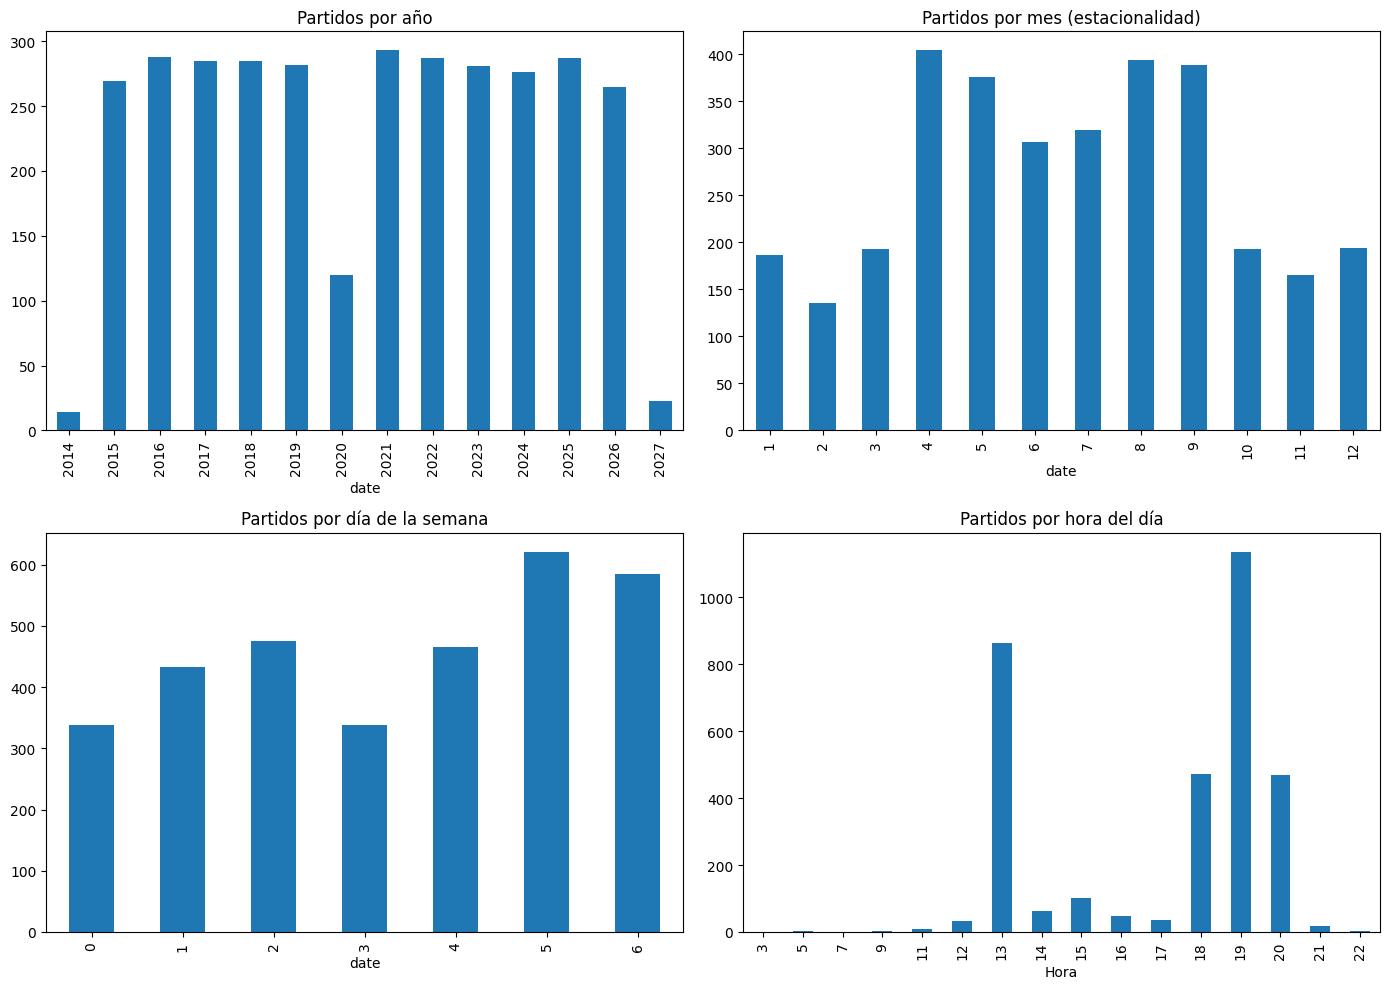

0      2014-10-31 20:00:00
1      2014-11-04 20:00:00
2      2014-11-08 20:00:00
3      2014-11-10 20:00:00
4      2014-11-15 20:00:00
               ...        
3252   2027-03-16 19:00:00
3253   2027-03-26 19:00:00
3254   2027-03-28 14:00:00
3255   2027-04-08 19:00:00
3256   2027-04-10 17:00:00
Name: date, Length: 3255, dtype: datetime64[us]

In [41]:
# 3. ANALISIS TEMPORAL
analisis_temporal(df_matches, date_col="date", date_format="%Y-%m-%d", evento="Partidos")

In [ ]:
# 4. ANALISIS GEOGRÁFICO
analisis_geografico(df_matches, lat_col='latitude', lon_col='longitude')